# Obesity Dataset - Data Exploration

In this notebook I'm going to explore the obesity prediction dataset and try to understand what the data looks like and clean it up for analysis.


## Loading the data

First I need to import libraries and load the dataset


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # to ignore warnings


In [58]:
# load the data
df = pd.read_csv("../data/obesity_prediction.csv")
print("Dataset loaded!")
print(f"Shape: {df.shape}")


Dataset loaded!
Shape: (2111, 17)


## Looking at the data

Let me see what the data looks like


In [59]:
# first few rows
df.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [60]:
# check the info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [61]:
# basic statistics
df.describe()


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## Checking data quality


In [62]:
# check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal: {df.isnull().sum().sum()}")  # looks like no missing values, that's good!


Missing values:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

Total: 0


In [63]:
# check duplicates
print(f"Duplicates: {df.duplicated().sum()}")


Duplicates: 24


## Data Cleaning

Now I need to clean the data before analyzing it


In [64]:
# make a copy so I don't mess up the original
df_clean = df.copy()
print(f"Starting with {df_clean.shape[0]} rows")


Starting with 2111 rows


### Handle missing values (if any)


In [65]:
# good news - no missing values in this dataset
print(f"Missing values: {df_clean.isnull().sum().sum()}")
# if there were any, I would fill them with median for numbers and mode for categories


Missing values: 0


### Remove duplicates


In [66]:
# no duplicates either
print(f"Duplicates: {df_clean.duplicated().sum()}")


Duplicates: 24


### Check if data makes sense


In [67]:
# checking if the values make sense
print("Checking age, height, weight ranges...")
print(f"Age: {df_clean['Age'].min():.0f} to {df_clean['Age'].max():.0f}")
print(f"Height: {df_clean['Height'].min():.2f}m to {df_clean['Height'].max():.2f}m")
print(f"Weight: {df_clean['Weight'].min():.1f}kg to {df_clean['Weight'].max():.1f}kg")
# looks reasonable!


Checking age, height, weight ranges...
Age: 14 to 61
Height: 1.45m to 1.98m
Weight: 39.0kg to 173.0kg


### Looking for outliers


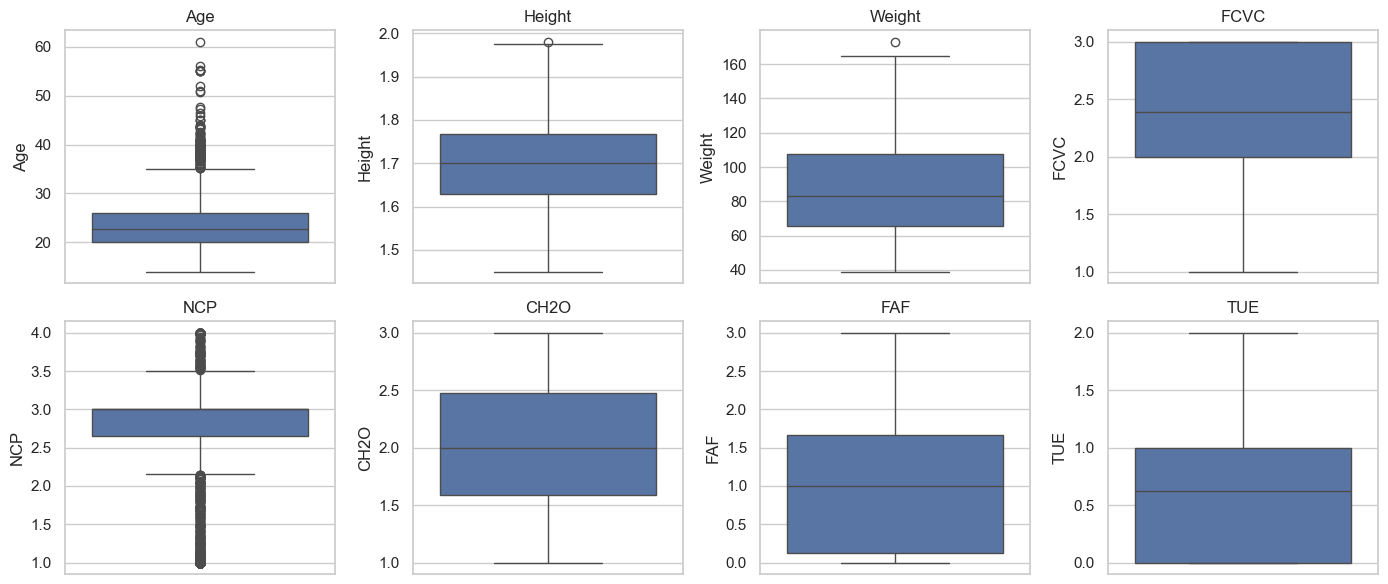

In [68]:
# making boxplots to see outliers
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

cols_to_check = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for idx, col in enumerate(cols_to_check):
    sns.boxplot(data=df_clean, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col}')

plt.tight_layout()
plt.show()
# there are some outliers but they might be valid for obesity data so I'll keep them


### Adding BMI column


BMI stats:
Min: 13.00
Max: 50.81
Mean: 29.70


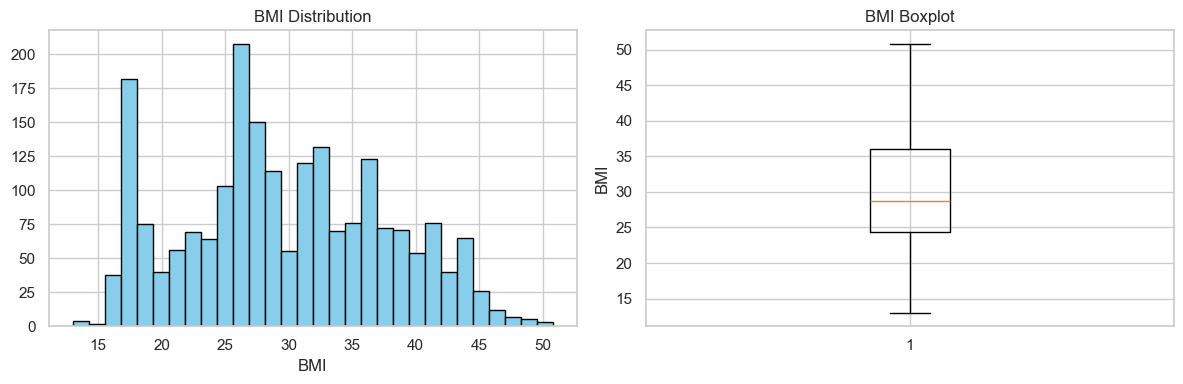

In [69]:
# I think BMI would be useful to have - formula is weight/height^2
df_clean['BMI'] = df_clean['Weight'] / (df_clean['Height'] ** 2)

print("BMI stats:")
print(f"Min: {df_clean['BMI'].min():.2f}")
print(f"Max: {df_clean['BMI'].max():.2f}")
print(f"Mean: {df_clean['BMI'].mean():.2f}")

# visualize BMI
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['BMI'], bins=30, color='skyblue', edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['BMI'])
plt.title('BMI Boxplot')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()


### Encoding categorical variables


In [70]:
# need to convert categories to numbers for machine learning later
df_encoded = df_clean.copy()

# converting yes/no to 1/0
binary_cols = ["family_history", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"no": 0, "yes": 1})

# Gender
df_encoded["Gender"] = df_encoded["Gender"].map({"Female": 0, "Male": 1})

# frequency columns
freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_encoded["CAEC"] = df_encoded["CAEC"].map(freq_map)
df_encoded["CALC"] = df_encoded["CALC"].map(freq_map)

print("Encoded categorical variables")


Encoded categorical variables


In [71]:
# encoding transportation and obesity levels
mtrans_map = {"Public_Transportation": 0, "Walking": 1, "Automobile": 2, "Motorbike": 3, "Bike": 4}
df_encoded["MTRANS"] = df_encoded["MTRANS"].map(mtrans_map)

obesity_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}
df_encoded["Obesity"] = df_encoded["Obesity"].map(obesity_map)

print(f"Encoded dataset shape: {df_encoded.shape}")


Encoded dataset shape: (2111, 18)


In [72]:
# check the cleaned data
print("Cleaned data shape:", df_clean.shape)
df_clean.head()


Cleaned data shape: (2111, 18)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,BMI
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


### Save the cleaned data


In [73]:
# saving the cleaned data for later use
df_clean.to_csv("../data/obesity_cleaned.csv", index=False)
df_encoded.to_csv("../data/obesity_numeric_cleaned.csv", index=False)
print("Saved cleaned datasets!")


Saved cleaned datasets!


## Data Visualization

Now let me visualize the data to understand patterns


### What categories do we have?


In [74]:
# looking at categorical columns
for col in ['Gender', 'Obesity', 'MTRANS']:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())



Gender:
Gender
Male      1068
Female    1043
Name: count, dtype: int64

Obesity:
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64


### Obesity distribution


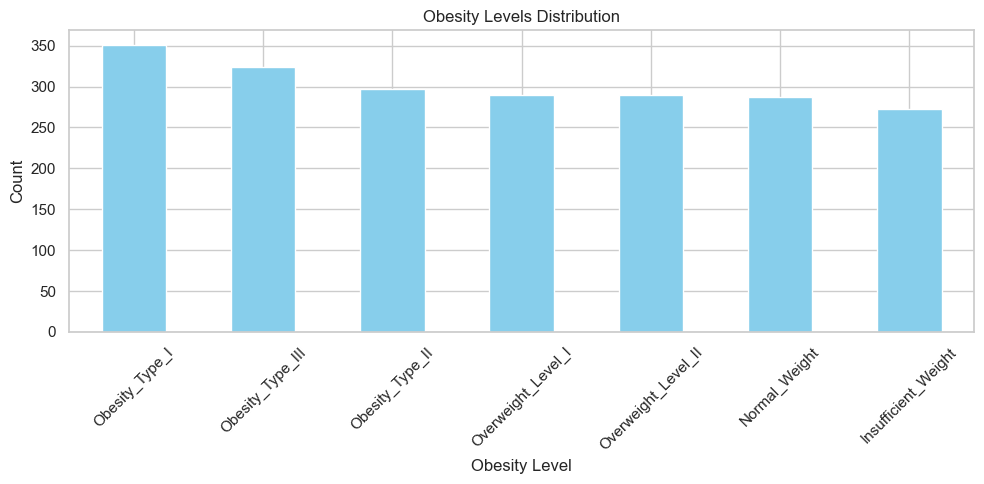

In [75]:
# plotting obesity distribution
plt.figure(figsize=(10, 5))
df_clean['Obesity'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Obesity Levels Distribution')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Age and Gender


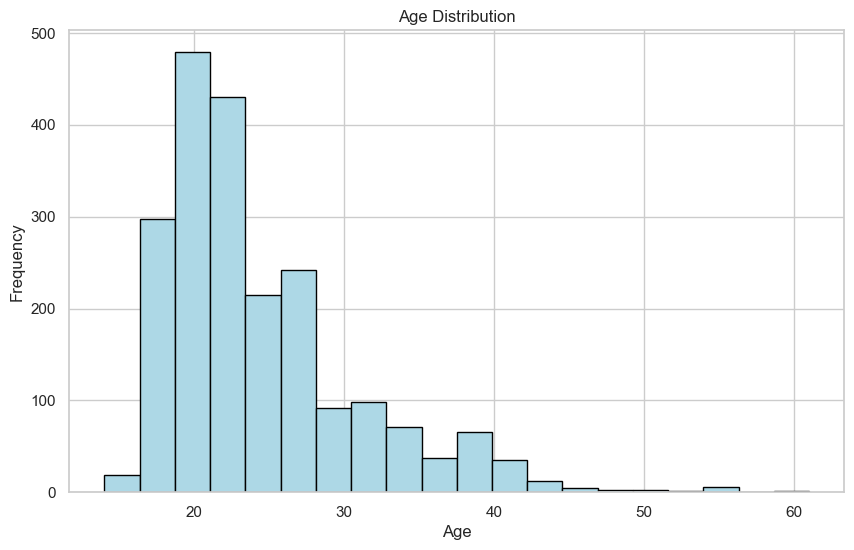

In [76]:
# age distribution
plt.hist(df_clean['Age'], bins=20, color='lightblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


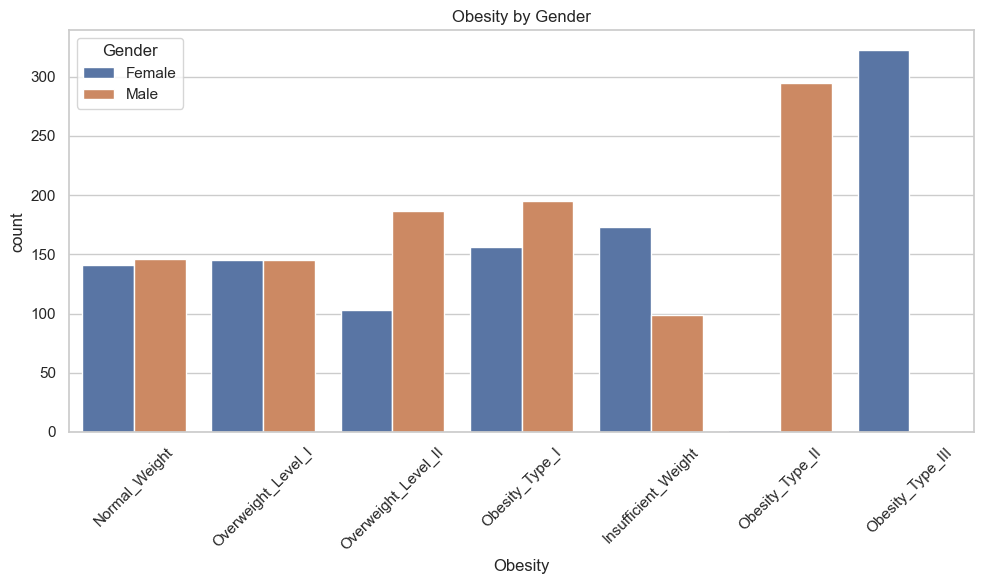

In [77]:
# obesity by gender
sns.countplot(data=df_clean, x='Obesity', hue='Gender')
plt.title('Obesity by Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Height vs Weight


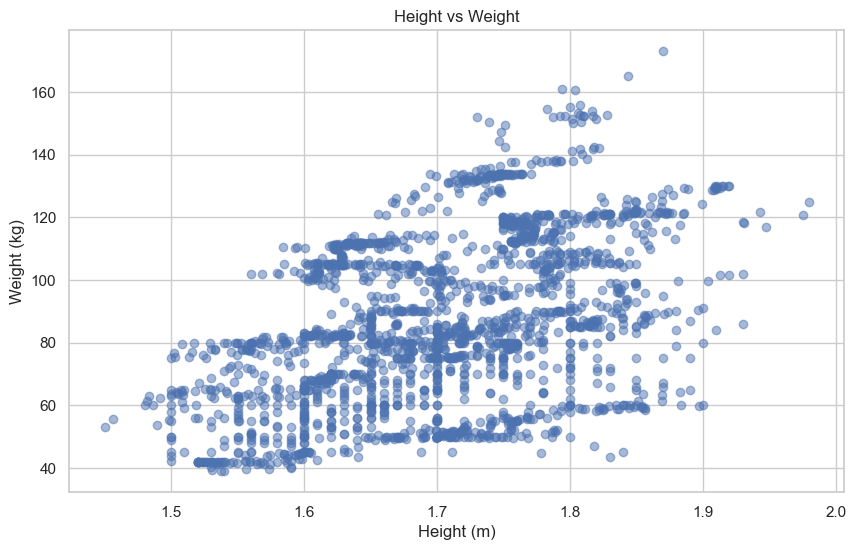

In [78]:
# scatter plot of height vs weight
plt.scatter(df_clean['Height'], df_clean['Weight'], alpha=0.5)
plt.title('Height vs Weight')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.show()


### Other interesting patterns


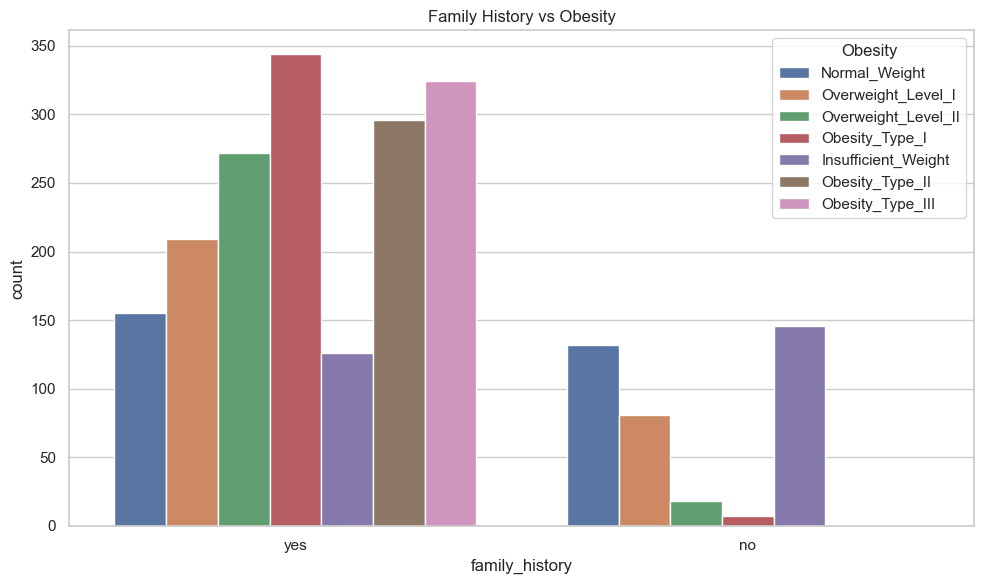

In [79]:
# does family history matter?
sns.countplot(data=df_clean, x='family_history', hue='Obesity')
plt.title('Family History vs Obesity')
plt.tight_layout()
plt.show()
# seems like it does!


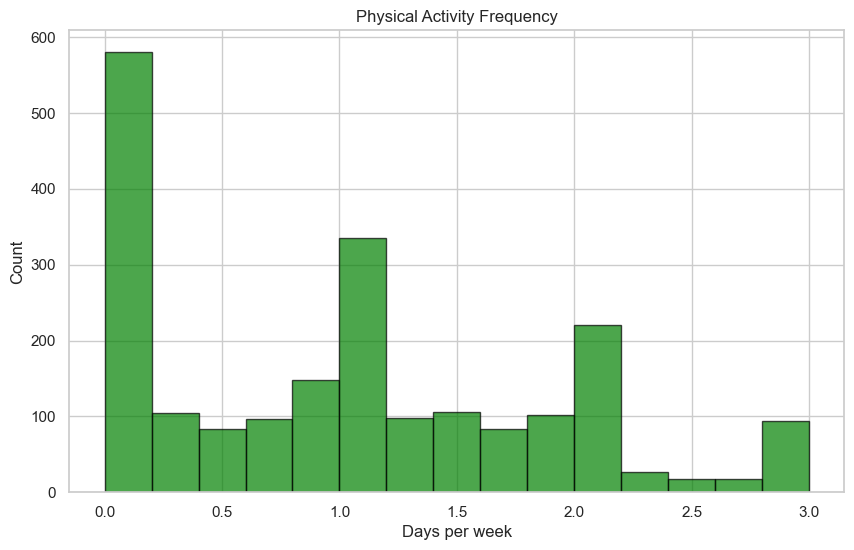

In [80]:
# physical activity frequency
plt.hist(df_clean['FAF'], bins=15, color='green', alpha=0.7, edgecolor='black')
plt.title('Physical Activity Frequency')
plt.xlabel('Days per week')
plt.ylabel('Count')
plt.show()


### Correlation heatmap


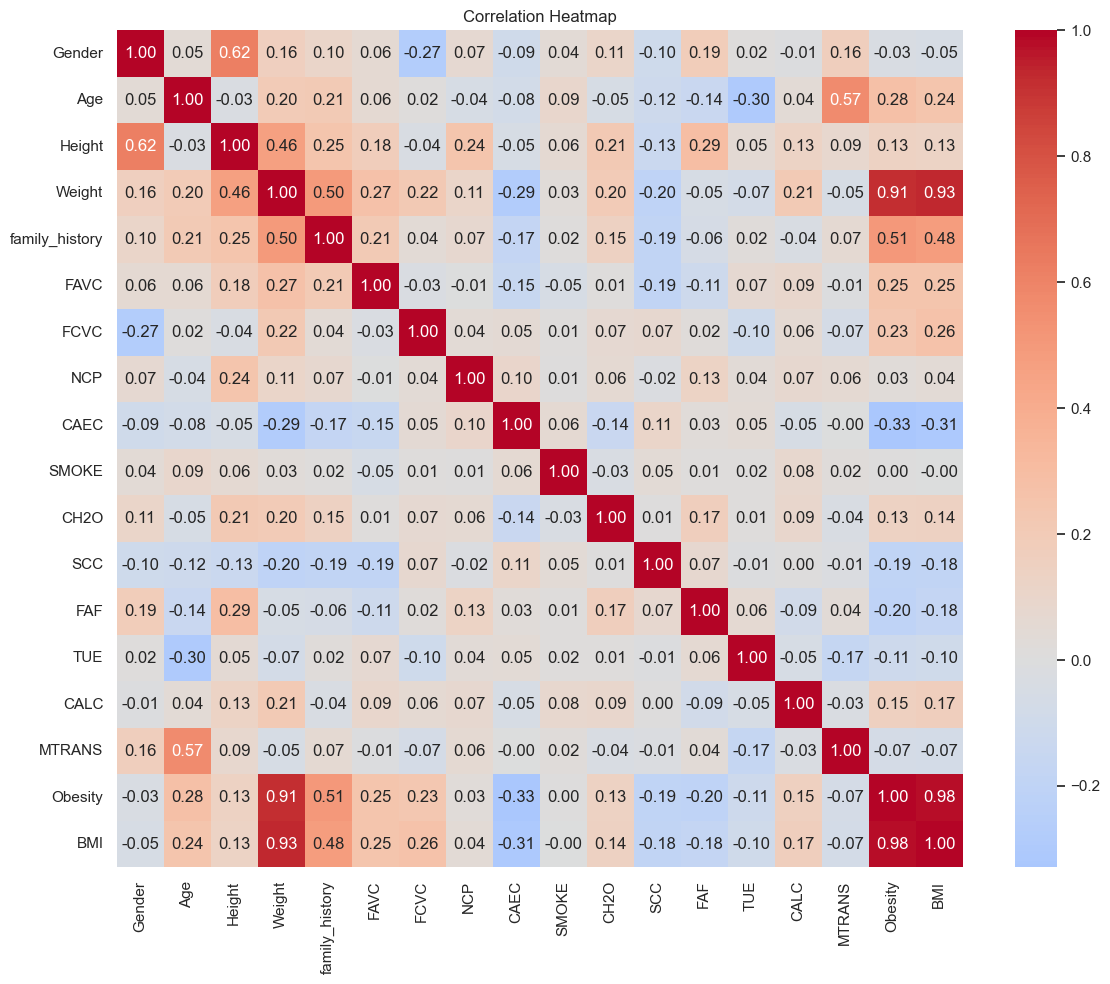

In [81]:
# correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [82]:
# what correlates most with obesity?
obesity_corr = df_encoded.corr()['Obesity'].sort_values(ascending=False)
print("Correlations with Obesity:")
print(obesity_corr)


Correlations with Obesity:
Obesity           1.000000
BMI               0.977826
Weight            0.913251
family_history    0.505148
Age               0.282913
FAVC              0.247793
FCVC              0.227759
CALC              0.151752
Height            0.133565
CH2O              0.133008
NCP               0.026690
SMOKE             0.003442
Gender           -0.031464
MTRANS           -0.067833
TUE              -0.107991
SCC              -0.194508
FAF              -0.199901
CAEC             -0.329350
Name: Obesity, dtype: float64


## Summary

What I learned from exploring this data:


In [83]:
print("Dataset Overview:")
print(f"- Total records: {df_clean.shape[0]}")
print(f"- Features: {df_clean.shape[1]}")
print(f"- No missing values")
print(f"\nKey findings:")
print("- BMI is highly correlated with obesity (makes sense!)")
print("- Family history seems to have an impact")
print("- Weight is strongly related to obesity levels")
print("- Age distribution is mostly young adults")


Dataset Overview:
- Total records: 2111
- Features: 18
- No missing values

Key findings:
- BMI is highly correlated with obesity (makes sense!)
- Family history seems to have an impact
- Weight is strongly related to obesity levels
- Age distribution is mostly young adults
